## Main Calculation
Checkpoint results are stored in `outputs/logs/` at regular intervals, `save_interval`.


In [1]:
import sys
sys.path.append('../src')

In [2]:
# Configuration and Parameters

data_dir = "Chestnut_Jove_2024_downsampled"
shape = "73_128_mask"
mask_shape = "73_128"
lambda_1 = 1000000      # Weight for boundary loss
lambda_2 = 500          # Weight for physics loss
sdf_pretrain="sphere"   # sphere or plane

mrc_file_path = f"../data/{data_dir}/{shape}.mrc"

GRID_SIZE = 64
NUM_CHECKPOINTS_TO_KEEP = 1000  # Checkpoint retention count (older ones get removed)
NUM_COLLOCATION = 1000

In [3]:
# === Lightweight checkpoint I/O: no Orbax, no layout/sharding headaches ===
import os, io, json, numpy as np, jax
from flax.serialization import to_bytes, from_bytes

def _ensure_dir(p):
    os.makedirs(p, exist_ok=True)

def save_state_bytes(path, state):
    # Materialize to host; training still runs on GPU.
    state_cpu = jax.device_get(jax.tree_util.tree_map(lambda x: x, state))
    data = to_bytes(state_cpu)  # msgpack bytes
    tmp = path + ".tmp"
    with open(tmp, "wb") as f:
        f.write(data)
    os.replace(tmp, path)  # atomic rename

def load_state_bytes(path, dummy_state):
    with open(path, "rb") as f:
        data = f.read()
    # Restore into dummy_state’s structure/shapes/dtypes
    return from_bytes(dummy_state, data)

def save_loss_npz(path, loss_obj: dict):
    # Ensure directory exists
    os.makedirs(os.path.dirname(path), exist_ok=True)

    safe = {k: np.asarray(v) for k, v in loss_obj.items()}
    tmp = path + ".tmp"   # e.g., ".../loss_000000.npz.tmp"

    # Write EXACTLY to tmp (avoid np.savez adding another .npz)
    with open(tmp, "wb") as f:
        np.savez(f, **safe)

    os.replace(tmp, path)  # atomic rename to ".../loss_000000.npz"

def load_loss_npz(path):
    if not os.path.exists(path):
        return None
    with np.load(path) as npz:
        return {k: npz[k] for k in npz.files}


In [4]:
import jax
import jax.numpy as jnp
print('jax:', jax.__version__)      # 0.7.2
print('devices:', jax.devices())    # [CudaDevice(id=0)]
import os
import numpy as np
import matplotlib.pyplot as plt
from pinn.train import create_train_state, train_step
from pinn.cryoet_io import load_mrc_data
# import pickle
# from flax.training import checkpoints
from pinn.utils import initial_loss
from tqdm.notebook import trange

# Initialize JAX random key
key = jax.random.PRNGKey(0)
# 
# Set directory for initial condition
# ckpt_dir = os.path.abspath(f"../outputs/logs/test_phase/snwitch2-2/30000/default")
# ckpt_dir = os.path.abspath(f"../outputs/logs/biconcave/round_1/lambda_5000000_1e-05/checkpoint_30000/")
# init_ckpt = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=None)

# Create train state
# state, model = create_train_state(key, lambda_1=lambda_1, lambda_2=lambda_2, learning_rate=1e-3, init_ckpt=init_ckpt)
state, model = create_train_state(key, lambda_1=lambda_1, lambda_2=lambda_2, sdf_pretrain=sdf_pretrain, learning_rate=1e-3)
print(f"Using lambda_1: {state.lambda_1}, lambda_2: {state.lambda_2}")

#### LOAD MRC DATA #####
# mrc_file_path = f"../data/synthetic/{shape}.mrc"
# missing_ratio=0.998
# mrc_file_path = f"../data/synthetic/biconcave_fragment_{str(missing_ratio).replace('.', '')}.mrc"
# flip_ratio=0.2
# mrc_file_path = f"../data/synthetic/biconcave_noisy_{str(flip_ratio).replace('.', '')}.mrc"
# sigma_blur = 5
# mrc_file_path = f"../data/synthetic/biconcave_blur_{str(sigma_blur).replace('.', '')}.mrc"
# num_patch=10
# rad_patch=25
# mrc_file_path = f"../data/synthetic/biconcave_patch_{num_patch}_{rad_patch}.mrc"

flip_ratio=0.175

cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)
print("MRC data loaded successfully! Shape:", cryoET_data.shape)
print("Cryo-ET Data Shape:", cryoET_data.shape)
print("Cryo-ET Data Min:", cryoET_data.min())
print("Cryo-ET Data Max:", cryoET_data.max())
print("Cryo-ET Unique Values:", jnp.unique(cryoET_data))

# Training Data
x_train = (jax.random.uniform(key, (NUM_COLLOCATION, 3), minval=-1, maxval=1)) # Sampled from [-1, 1]^3


# Training loop
num_steps = 10000
# num_steps = 1000
save_interval = 100


# # temporary 
# binary_mask = jnp.where(cryoET_data > 0.8, 1, 0)
# membrane_indices = jnp.where(binary_mask.ravel() == 1)[0]

checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}")

# if checkpoint_dir already exists, remove it
if os.path.exists(checkpoint_dir):
    print(f"Checkpoint directory {checkpoint_dir} already exists. Removing it.")
    import shutil
    shutil.rmtree(checkpoint_dir)

# checkpoints.save_checkpoint(
#     ckpt_dir=checkpoint_dir,
#     target={"state": state, "loss": initial_loss(state, x_train, cryoET_data, (64,64,64))},
#     # target={"state": state, "loss": initial_loss(state, x_train, cryoET_data, membrane_indices)},
#     step=0,
#     overwrite=False,
#     keep=NUM_CHECKPOINTS_TO_KEEP,
# )
loss0 = initial_loss(state, x_train, cryoET_data, (GRID_SIZE, GRID_SIZE, GRID_SIZE))

_ensure_dir(checkpoint_dir)
save_state_bytes(os.path.join(checkpoint_dir, "state_000000.msgpack"), state)
save_loss_npz(os.path.join(checkpoint_dir, "loss_000000.npz"), loss0)
print("Saved step 0.")
print(sorted(os.listdir(checkpoint_dir))[:6])

loss_history = []

# for step in range(num_steps):
for step in trange(num_steps):
    state, loss_val, loss_data_val, loss_physics_val = train_step(state, x_train, cryoET_data)
    # state, loss_val, loss_data_val, loss_physics_val = train_step(state, x_train, cryoET_data, membrane_indices)

    loss_history.append({
        "step": step + 1,
        "total_loss": loss_val,
        "data_loss": loss_data_val,
        "physics_loss": loss_physics_val
    })

    if (step+1) % save_interval == 0:

        # loss_history = {key: np.array([entry[key] for entry in loss_history]) for key in loss_history[0].keys()}
        
        # checkpoints.save_checkpoint(
        #     ckpt_dir = checkpoint_dir,
        #     target={"state": state, "loss": loss_history},
        #     step=step+1, 
        #     overwrite=False, 
        #     keep=NUM_CHECKPOINTS_TO_KEEP,
        # )
        # print(f"Checkpoint saved at step {step+1}")

        # loss_history = []

        # Convert history list-of-dicts → dict-of-arrays
        loss_history_np = {k: np.asarray([e[k] for e in loss_history]) for k in loss_history[0].keys()}

        step_tag = f"{step+1:06d}"
        save_state_bytes(os.path.join(checkpoint_dir, f"state_{step_tag}.msgpack"), state)
        save_loss_npz(os.path.join(checkpoint_dir, f"loss_{step_tag}.npz"), loss_history_np)
        print(f"Saved step {step+1}")

        loss_history = []



jax: 0.7.2
devices: [CudaDevice(id=0)]
Pretraining the network using SDF...
Using lambda_1: 1000000, lambda_2: 500
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
MRC data loaded successfully! Shape: (64, 64, 64)
Cryo-ET Data Shape: (64, 64, 64)
Cryo-ET Data Min: 0.0
Cryo-ET Data Max: 0.99999994
Cryo-ET Unique Values: [0.0000000e+00 2.2964436e-12 4.5928873e-12 ... 9.9999678e-01 9.9999952e-01
 9.9999994e-01]


/home/minisemin/anaconda3/envs/pinn/lib/python3.11/site-packages/jax/_src/numpy/lax_numpy.py:5943: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in arange is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return _arange(start, stop=stop, step=step, dtype=dtype,


Saved step 0.
['loss_000000.npz', 'state_000000.msgpack']


  0%|          | 0/10000 [00:00<?, ?it/s]

Saved step 100
Saved step 200
Saved step 300
Saved step 400
Saved step 500
Saved step 600
Saved step 700
Saved step 800
Saved step 900
Saved step 1000
Saved step 1100
Saved step 1200
Saved step 1300
Saved step 1400
Saved step 1500
Saved step 1600
Saved step 1700
Saved step 1800
Saved step 1900
Saved step 2000
Saved step 2100
Saved step 2200
Saved step 2300
Saved step 2400
Saved step 2500
Saved step 2600
Saved step 2700
Saved step 2800
Saved step 2900
Saved step 3000
Saved step 3100
Saved step 3200
Saved step 3300
Saved step 3400
Saved step 3500
Saved step 3600
Saved step 3700
Saved step 3800
Saved step 3900
Saved step 4000
Saved step 4100
Saved step 4200
Saved step 4300
Saved step 4400
Saved step 4500
Saved step 4600
Saved step 4700
Saved step 4800
Saved step 4900
Saved step 5000
Saved step 5100
Saved step 5200
Saved step 5300
Saved step 5400
Saved step 5500
Saved step 5600
Saved step 5700
Saved step 5800
Saved step 5900
Saved step 6000
Saved step 6100
Saved step 6200
Saved step 6300
S

### Analysis

/home/minisemin/matsulab/pinn-exploration-model/outputs/logs/73_128_mask/lambda_1000000_500
Pretraining the network using SDF...
Loading /home/minisemin/matsulab/pinn-exploration-model/outputs/logs/73_128_mask/lambda_1000000_500/state_000000.msgpack
Loading /home/minisemin/matsulab/pinn-exploration-model/outputs/logs/73_128_mask/lambda_1000000_500/state_000100.msgpack
Loading /home/minisemin/matsulab/pinn-exploration-model/outputs/logs/73_128_mask/lambda_1000000_500/state_000200.msgpack
Loading /home/minisemin/matsulab/pinn-exploration-model/outputs/logs/73_128_mask/lambda_1000000_500/state_000300.msgpack
Loading /home/minisemin/matsulab/pinn-exploration-model/outputs/logs/73_128_mask/lambda_1000000_500/state_000400.msgpack
Loading /home/minisemin/matsulab/pinn-exploration-model/outputs/logs/73_128_mask/lambda_1000000_500/state_000500.msgpack
Loading /home/minisemin/matsulab/pinn-exploration-model/outputs/logs/73_128_mask/lambda_1000000_500/state_000600.msgpack
Loading /home/minisemin/

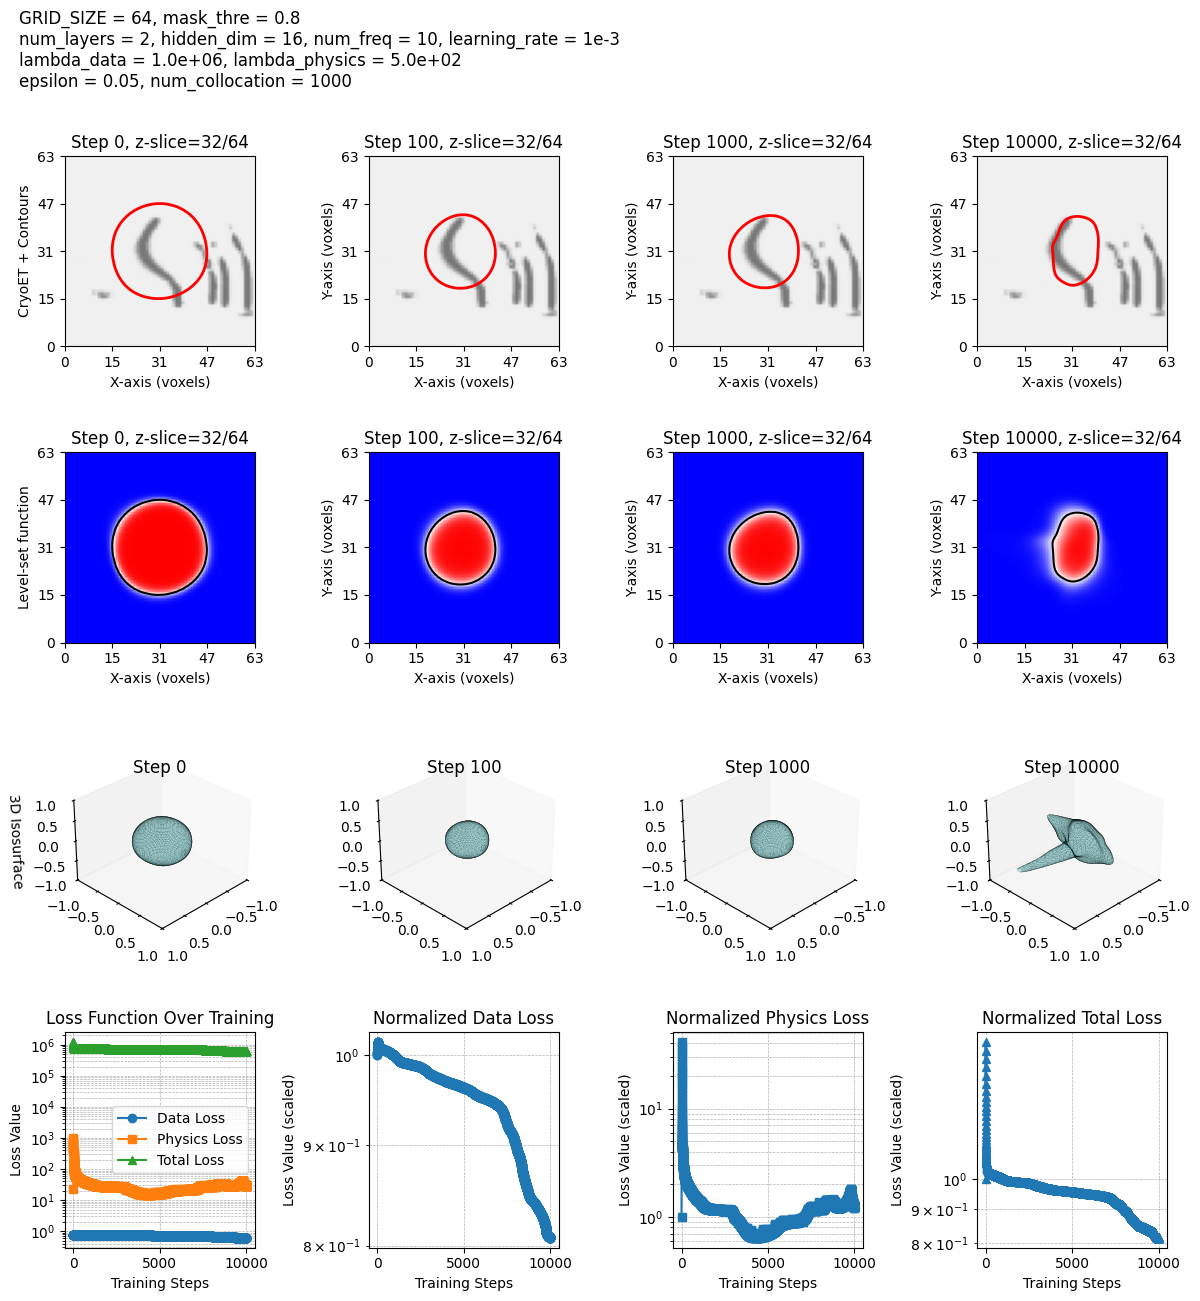

In [13]:
## make one combined image file

import os
import numpy as np
import jax
import matplotlib.pyplot as plt
# from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_result,
    visualize_cryoET_with_contours,
    plot_3d_isosurface,
    plot_loss_history_ax,
    plot_normalized_loss_history_ax,
)
from pinn.utils import assemble_loss_history
from pinn.train import create_train_state

num_layers = 2

# steps_to_visualize = [0, 200, 600, 1000]
# steps_series = list(range(0, 1001, 100))
steps_to_visualize = [0, 100, 1000, 10000]
steps_series = list(range(0, 10001, 100))

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}")
print(checkpoint_dir)

# Build a dummy TrainState to give from_bytes() the structure/shapes (values will be overwritten)
dummy_key = jax.random.PRNGKey(0)
dummy_state, _ = create_train_state(
    dummy_key,
    lambda_1=lambda_1,
    lambda_2=lambda_2,
    sdf_pretrain=sdf_pretrain,   # same arg you used in training; or None if not used
    learning_rate=1e-3,
)

# 2) Load checkpoints safely
checkpoint_data = {}
for step in steps_series:
    step_tag = f"{step:06d}"
    state_path = os.path.join(checkpoint_dir, f"state_{step_tag}.msgpack")
    loss_path  = os.path.join(checkpoint_dir, f"loss_{step_tag}.npz")
    if os.path.exists(state_path):
        print(f"Loading {state_path}")
        restored_state = load_state_bytes(state_path, dummy_state)  # TrainState
        loss_blob = load_loss_npz(loss_path)                        # dict or None
        checkpoint_data[step] = {
            "state": {"params": restored_state.params},  # ← 여기서 wrap
            "loss": loss_blob,
        }

# Load CryoET data
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

# Create a big figure with 4 rows: cryoET + contours, prediction result, 3D isosurface, and leave room for loss plots
fig = plt.figure(figsize=(3*4, 12))

# Row 1: visualize_cryoET_with_contours
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, i + 1)
    visualize_cryoET_with_contours(ax, step, checkpoint_data[step], cryoET_data, grid_size=GRID_SIZE, slice_index=32, axis="z")
    if i == 0:
        ax.set_ylabel("CryoET + Contours")

# Row 2: visualize_checkpoint_result
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 4 + i + 1)
    visualize_checkpoint_result(ax, step, checkpoint_data[step], grid_size=GRID_SIZE, slice_index=32, axis="z")
    if i == 0:
        ax.set_ylabel("Level-set function")

# Row 3: plot_3d_isosurface
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 8 + i + 1, projection='3d')
    plot_3d_isosurface(ax, step, checkpoint_data[step], grid_size=GRID_SIZE)
    if i == 0:
        ax.set_zlabel("3D Isosurface", rotation=180)

# Row 4: loss history
assembled_loss = assemble_loss_history(checkpoint_data)
ax = fig.add_subplot(4, 4, 12+1)
plot_loss_history_ax(ax, assembled_loss)
for i in [0,1,2]:
    ax = fig.add_subplot(4, 4, 12+i+2)
    plot_normalized_loss_history_ax(ax, i, assembled_loss)
    

info_text = (
    f"GRID_SIZE = {GRID_SIZE}, mask_thre = 0.8\n"
    f"num_layers = {num_layers}, hidden_dim = 16, num_freq = 10, learning_rate = 1e-3\n"
    f"lambda_data = {lambda_1:.1e}, lambda_physics = {lambda_2:.1e}\n"
    f"epsilon = 0.05, num_collocation = {NUM_COLLOCATION}"
)

fig.text(
    0.02, 1.08,  # (x, y) position in figure coordinates
    info_text,
    fontsize=12,
    ha='left',
    va='top'
)

plt.tight_layout()
# plt.savefig("../outputs/figs/analysis.png", dpi=300, bbox_inches="tight")
plt.show()

# save the plot
fig.savefig(os.path.join(checkpoint_dir, f"analysis1_{shape}_lambda_{lambda_1}_{lambda_2}.png"), dpi=300, bbox_inches="tight")

#### Physics Analysis

Pretraining the network using SDF...
Resizing MRC data from (128, 128, 128) to (64, 64, 64)


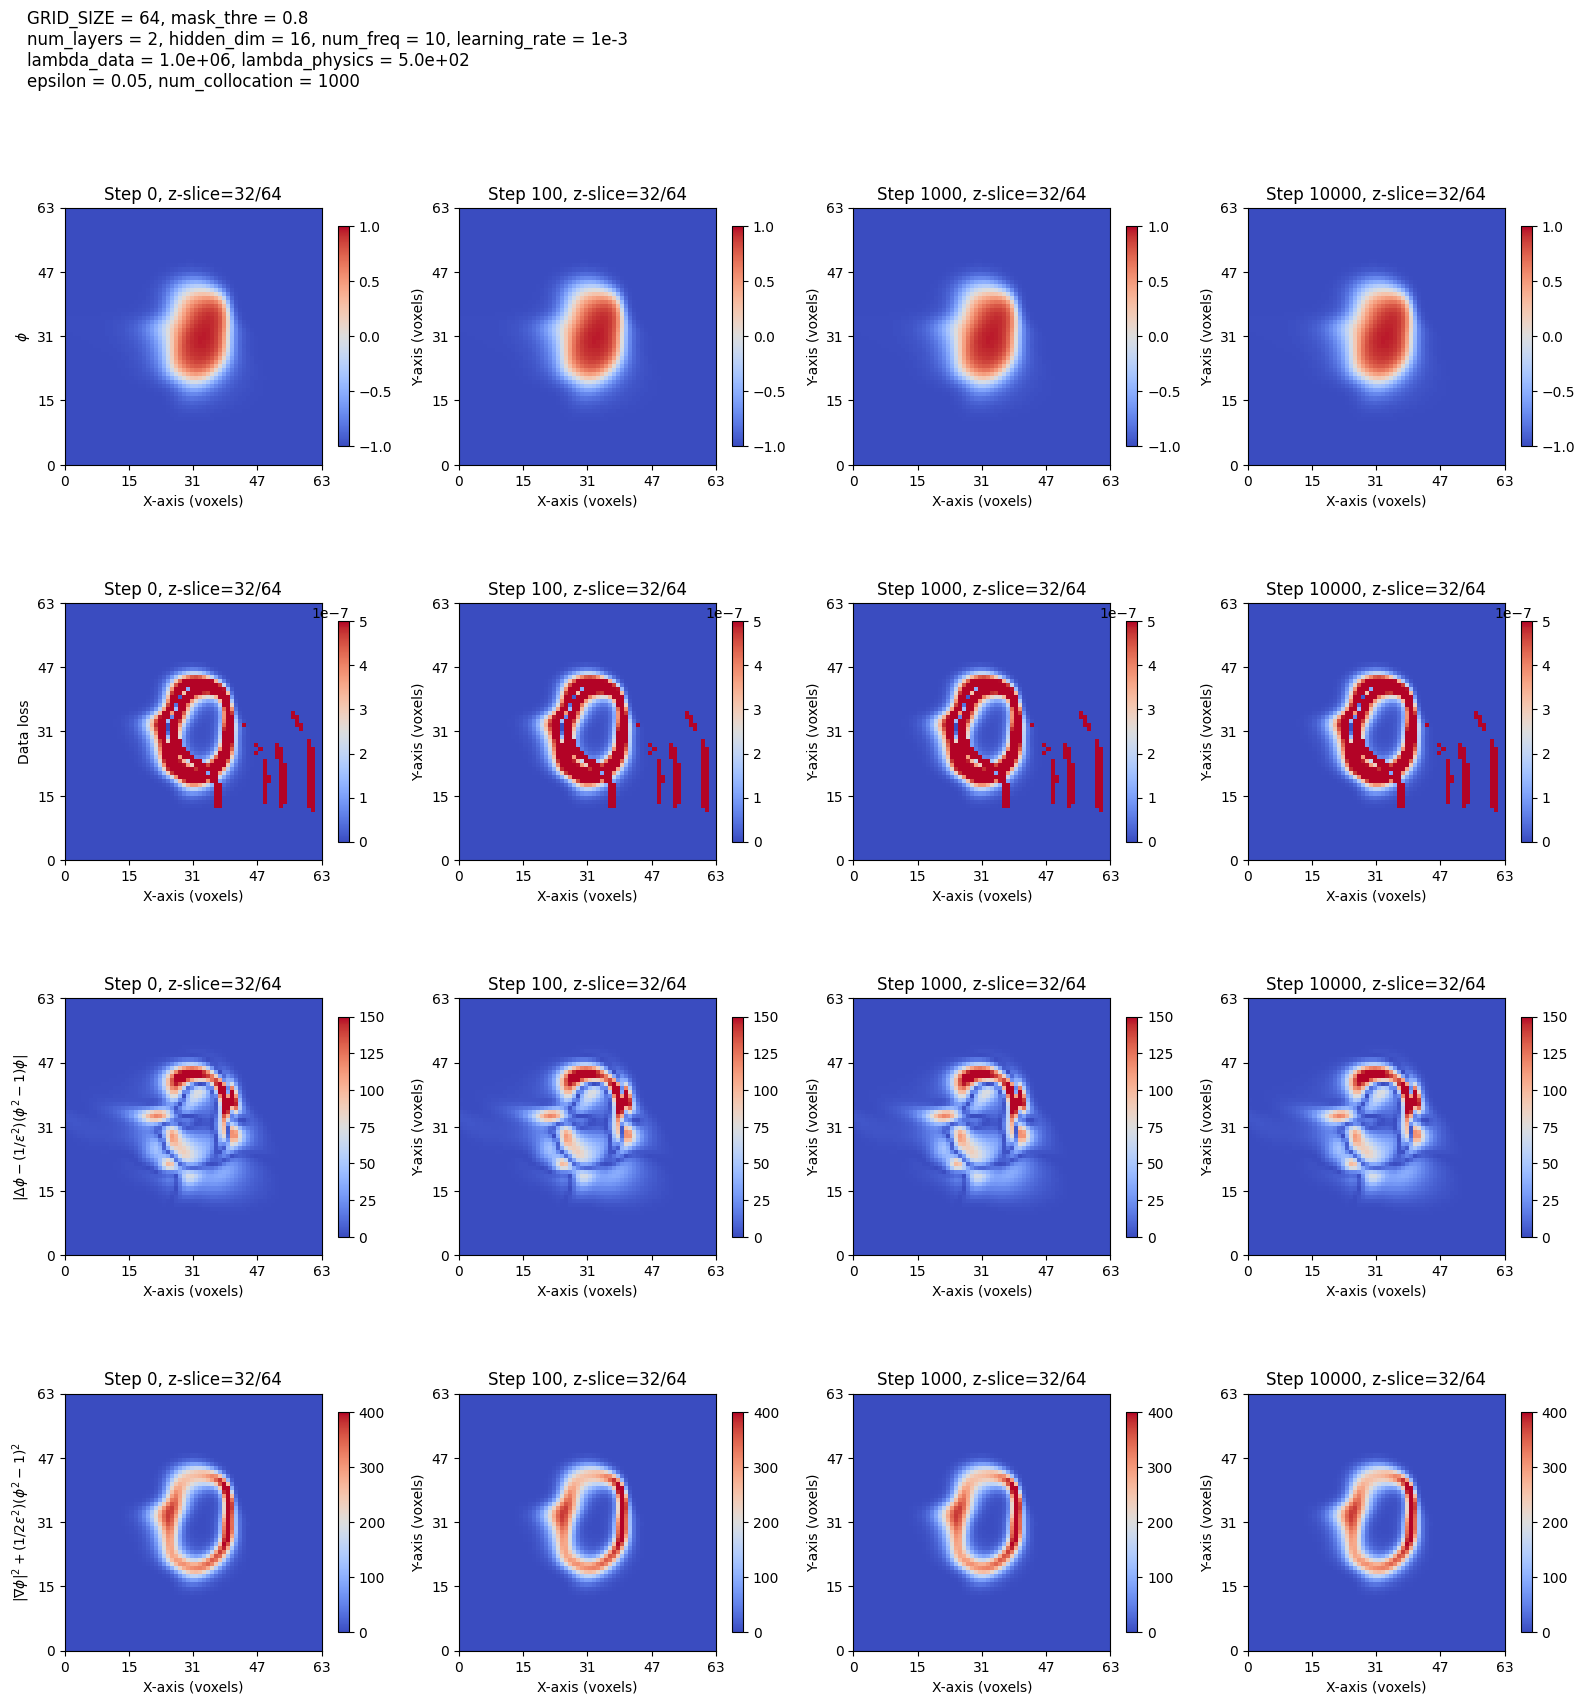

In [6]:
## make one combined physics analysis image

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_result,
    visualize_physics_loss,
)
from pinn.train import create_train_state   
from pinn.utils import assemble_loss_history
import jax

# lambda_1 = 5000000
# lambda_2 = 1
num_layers = 2
epsilon = 0.05
# shape = "multi"

# steps_to_visualize = [0, 200, 600, 1000]
# steps_to_visualize = [0, 2000, 6000, 10000]
# steps_to_visualize = [0, 1000, 6000, 10000]
steps_to_visualize = [0, 100, 1000, 10000]
# steps_to_visualize = [0, 10000, 20000, 30000]
# steps_to_visualize = [0, 30000, 60000, 90000]

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}")

# Dummy state (template)
dummy_key = jax.random.PRNGKey(0)
dummy_state, _ = create_train_state(
    dummy_key,
    lambda_1=lambda_1,
    lambda_2=lambda_2,
    sdf_pretrain=sdf_pretrain,
    learning_rate=1e-3,
)

# checkpoint_data = {}
# for step in steps_to_visualize:
#     checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
#     checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)
# Load checkpoints (msgpack/npz)
checkpoint_data = {}
for step in steps_to_visualize:
    step_tag = f"{step:06d}"
    state_path = os.path.join(checkpoint_dir, f"state_{step_tag}.msgpack")
    loss_path  = os.path.join(checkpoint_dir, f"loss_{step_tag}.npz")
    if os.path.exists(state_path):
        restored_state = load_state_bytes(state_path, dummy_state)
        loss_blob = load_loss_npz(loss_path)
        checkpoint_data[step] = {"state": restored_state, "loss": loss_blob}

# Load CryoET data
# mrc_file_path = f"../data/synthetic/{shape}.mrc"
# mrc_file_path = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}.mrc"
# mrc_file_path = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}_w{wedge_axis}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)


# Create a big figure with 4 rows: cryoET + contours, prediction result, 3D isosurface, and leave room for loss plots
fig = plt.figure(figsize=(4*4, 4*4))


# Row 1: Phi
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, i + 1)
    checkpoint_data[step] = {
    "state": {"params": restored_state.params},
    "loss": loss_blob, 
    }
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="phi",
                           grid_size=GRID_SIZE, slice_index=32, axis="z", vmin=-1, vmax=1)
    # visualize_checkpoint_result(ax, step, checkpoint_data[step], grid_size=GRID_SIZE, slice_index=32, axis="z", colorbar = True)
    if i == 0:
        ax.set_ylabel(r"$\phi$")

# Row 2: data loss
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 4 + i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="data",
                           grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", vmin=0, vmax=5e-7, cryoET_data=cryoET_data)
    if i == 0:
        ax.set_ylabel(r"Data loss")

# Row 3: physics loss
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 8 + i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="residual",
                           grid_size=GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax=150)

    if i == 0:
        ax.set_ylabel(r"$|\Delta \phi - (1/\epsilon^2)(\phi^2 - 1)\phi|$")

# Row 4: tension energy
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 12 + i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="tension",
                           grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", vmin=0, vmax=400)
    if i == 0:
        ax.set_ylabel(r"$|\nabla \phi|^2 + (1/2\epsilon^2) (\phi^2 -1)^2$")
        # ax.set_ylabel(r"$|\nabla\phi|^2$")


info_text = (
    f"GRID_SIZE = {GRID_SIZE}, mask_thre = 0.8\n"
    f"num_layers = {num_layers}, hidden_dim = 16, num_freq = 10, learning_rate = 1e-3\n"
    f"lambda_data = {lambda_1:.1e}, lambda_physics = {lambda_2:.1e}\n"
    f"epsilon = {epsilon}, num_collocation = {NUM_COLLOCATION}"
)

fig.text(
    0.02, 1.08,  # (x, y) position in figure coordinates
    info_text,
    fontsize=12,
    ha='left',
    va='top'
)

plt.tight_layout()
# plt.savefig("../outputs/figs/physics.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
# Make a movie

import matplotlib.pyplot as plt
import os
from pinn.plot import plot_3d_isosurface
from pinn.train import create_train_state
from flax.training import checkpoints
import imageio
import re

steps_to_visualize = list(range(0, 30001, 1000))
log_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}/")
frame_dir = os.path.join(log_dir, f"frames")

# Dummy template
dummy_key = jax.random.PRNGKey(0)
dummy_state, _ = create_train_state(
    dummy_key,
    lambda_1=lambda_1,
    lambda_2=lambda_2,
    sdf_pretrain=sdf_pretrain,
    learning_rate=1e-3,
)

# def save_isosurface_frame(step, checkpoint, save_dir="frames", grid_size=64):
#     fig = plt.figure(figsize=(6, 6))
#     ax = fig.add_subplot(111, projection='3d')
#     plot_3d_isosurface(ax, step, checkpoint, grid_size)
    
#     os.makedirs(save_dir, exist_ok=True)
#     filename = os.path.join(save_dir, f"frame_{step:06d}.png")
#     plt.savefig(filename, dpi=150)
#     plt.close(fig)
def save_isosurface_frame(step, checkpoint, save_dir, grid_size=64):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    plot_3d_isosurface(ax, step, checkpoint, grid_size)
    os.makedirs(save_dir, exist_ok=True)
    filename = os.path.join(save_dir, f"frame_{step:06d}.png")
    plt.savefig(filename, dpi=150)
    plt.close(fig)


# def make_movie_from_frames(frame_dir="frames", output="movie.mp4", fps=12, start=0, end=30000):
#     # Match files like frame_XXXX.png and extract the numeric part
#     pattern = re.compile(r"frame_(\d+)\.png")

#     frames = []
#     for fname in os.listdir(frame_dir):
#         match = pattern.match(fname)
#         if match:
#             index = int(match.group(1))
#             if start <= index <= end:
#                 frames.append((index, os.path.join(frame_dir, fname)))

#     frames.sort(key=lambda x: x[0])

#     with imageio.get_writer(output, fps=fps) as writer:
#         for _, frame_path in frames:
#             image = imageio.imread(frame_path)
#             writer.append_data(image)
def make_movie_from_frames(frame_dir, output="movie.mp4", fps=12, start=0, end=30000):
    pattern = re.compile(r"frame_(\d+)\.png")
    frames = []
    for fname in os.listdir(frame_dir):
        m = pattern.match(fname)
        if m:
            idx = int(m.group(1))
            if start <= idx <= end:
                frames.append((idx, os.path.join(frame_dir, fname)))
    frames.sort(key=lambda x: x[0])
    with imageio.get_writer(output, fps=fps) as writer:
        for _, fp in frames:
            writer.append_data(imageio.imread(fp))


# for step in steps_to_visualize:
#     ckpt_path = os.path.join(log_dir, f"checkpoint_{step}")
#     ckpt_data = checkpoints.restore_checkpoint(ckpt_dir=ckpt_path, target=None)
#     print(f"saving step {step}")
#     save_isosurface_frame(step, ckpt_data, save_dir=frame_dir)

# Render frames
for step in steps_to_visualize:
    step_tag = f"{step:06d}"
    state_path = os.path.join(log_dir, f"state_{step_tag}.msgpack")
    if os.path.exists(state_path):
        restored_state = load_state_bytes(state_path, dummy_state)
        print(f"saving step {step}")
        # match the dict structure expected by plot_3d_isosurface
        # save_isosurface_frame(step, {"state": restored_state}, save_dir=frame_dir, grid_size=GRID_SIZE)
        # wrap TrainState -> old dict shape expected by plot_3d_isosurface
        save_isosurface_frame(step, {"state": {"params": restored_state.params}}, save_dir=frame_dir, grid_size=GRID_SIZE)

# Make the movie
output = os.path.abspath(os.path.join(frame_dir, f"{shape}_lambda_{lambda_1}_{lambda_2}.mp4"))
make_movie_from_frames(frame_dir=frame_dir, output=output)
print("Wrote:", output)

Pretraining the network using SDF...
saving step 0
saving step 1000
saving step 2000
saving step 3000
saving step 4000
saving step 5000
saving step 6000
saving step 7000
saving step 8000
saving step 9000
saving step 10000


/tmp/ipykernel_25909/2129506929.py:74: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(fp))
/home/minisemin/anaconda3/envs/pinn/lib/python3.11/subprocess.py:1885: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


Wrote: /home/minisemin/matsulab/pinn-exploration-model/outputs/logs/73_128_mask/lambda_1000000_500/frames/73_128_mask_lambda_1000000_500.mp4


### Compare the result with the segmented mask

In [8]:
# -------------------------
# Helper: find last saved step (msgpack)
# -------------------------
def find_last_state_path(ckpt_dir):
    last_path = None
    last_step = -1
    pat = re.compile(r"state_(\d{6})\.msgpack$")
    for fn in os.listdir(ckpt_dir):
        m = pat.match(fn)
        if m:
            s = int(m.group(1))
            if s > last_step:
                last_step = s
                last_path = os.path.join(ckpt_dir, fn)
    return last_path, last_step


In [9]:
# lambda_1 = 1000000      # Weight for boundary loss
# lambda_2 = 1000          # Weight for physics loss

Pretraining the network using SDF...
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
[step 10000] band=0.075
Dice: 0.0544 | IoU: 0.0280 | Precision: 0.3876 | Recall: 0.0293 | Accuracy: 0.9262
ASSD: 0.1605 | HD95: 0.8114 (in normalized units)


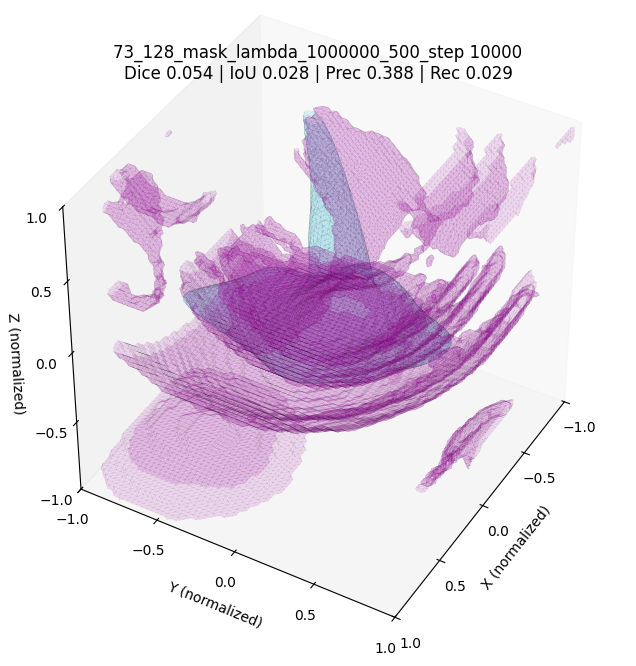

In [10]:
import os, re
import numpy as np
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage.measure import marching_cubes
from scipy.spatial import cKDTree  # optional, for surface distance metrics

from pinn.cryoet_io import load_mrc_data
from pinn.train import create_train_state
from pinn.model import PINN

# Load the final data and the segmented mask
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}")
mask_file_path = f"../data/{data_dir}/{mask_shape}_mask.mrc"

# pick a band around phi=0 to approximate the membrane thickness in voxels
epsilon = 0.05
band = 1.5 * epsilon  # you can tune: 1.0~2.0 * epsilon is typical

state_path, num_steps = find_last_state_path(checkpoint_dir)
assert state_path is not None, "No state_*.msgpack found."

# -------------------------
# Restore model
# -------------------------
dummy_key = jax.random.PRNGKey(0)
dummy_state, _ = create_train_state(
    dummy_key,
    lambda_1=lambda_1,
    lambda_2=lambda_2,
    sdf_pretrain=sdf_pretrain,
    learning_rate=1e-3,
)
restored_state = load_state_bytes(state_path, dummy_state)  # TrainState with .params as you saved
params = restored_state.params

# Build model
model = PINN()  # your class defaults: hidden_dim=16, num_frequencies=10

# -------------------------
# Load ground-truth mask and evaluate φ on the grid
# -------------------------
mask_data = load_mrc_data(mask_file_path, grid_size=GRID_SIZE)  # float in {0,1} or [0,1]
mask = (np.asarray(mask_data) > 0.5).astype(np.uint8)           # binary GT membrane voxels

g = jnp.linspace(-1, 1, GRID_SIZE)
X, Y, Z = jnp.meshgrid(g, g, g, indexing="ij")
points = jnp.stack([X.ravel(), Y.ravel(), Z.ravel()], axis=-1)

# IMPORTANT: your TrainState.params is a full variables dict (incl. 'params'),
# and your code elsewhere uses model.apply(params, x). We do the same:
phi = model.apply(params, points)
phi = phi.reshape((GRID_SIZE, GRID_SIZE, GRID_SIZE))


# -------------------------
# Predicted membrane mask from a narrow band: |φ| ≤ band
# -------------------------
pred_mask = (np.abs(np.asarray(phi)) <= band).astype(np.uint8)


# -------------------------
# Metrics (membrane class)
# -------------------------
TP = np.logical_and(pred_mask == 1, mask == 1).sum()
FP = np.logical_and(pred_mask == 1, mask == 0).sum()
FN = np.logical_and(pred_mask == 0, mask == 1).sum()
TN = np.logical_and(pred_mask == 0, mask == 0).sum()
N  = mask.size

dice = (2 * TP) / (2 * TP + FP + FN + 1e-8)
iou  = TP / (TP + FP + FN + 1e-8)
prec = TP / (TP + FP + 1e-8)
rec  = TP / (TP + FN + 1e-8)
acc  = (TP + TN) / N

print(f"[step {num_steps}] band={band:.3f}")
print(f"Dice: {dice:.4f} | IoU: {iou:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | Accuracy: {acc:.4f}")


# -------------------------
# (Optional) surface distance metrics using meshes
# -------------------------
def surface_from_volume(vol, level, spacing):
    """
    Make a writable, C-contiguous float32 NumPy array for skimage.marching_cubes.
    Apply the SAME orientation (transpose) to all volumes if you choose to.
    """
    # Bring to host, ensure dtype/contiguity, and make it writable
    v = np.array(jax.device_get(vol), dtype=np.float32, order="C", copy=True)
    # If elsewhere you used a transpose (e.g., phi = phi.T), apply it here to BOTH
    # v = v.transpose(2, 1, 0)  # <- only if you decide to reorient consistently

    verts, faces, _, _ = marching_cubes(
        v,
        level=level,
        spacing=spacing,
        allow_degenerate=False,   # reduces weird triangles
        method="lewiner",
    )
    return verts, faces


spacing = (2.0 / GRID_SIZE, 2.0 / GRID_SIZE, 2.0 / GRID_SIZE)

# Predicted surface at φ=0, GT surface at mask=0.5
pred_verts, pred_faces = surface_from_volume(phi,   level=0.0, spacing=spacing)
gt_verts,   gt_faces   = surface_from_volume(mask,  level=0.5, spacing=spacing)

# shift to [-1,1]^3 to match your plotting convention
pred_verts -= 1.0
gt_verts   -= 1.0


# Average Symmetric Surface Distance (ASSD) & Hausdorff (optional)
try:
    t_pred = cKDTree(pred_verts); t_gt = cKDTree(gt_verts)
    d_pred_to_gt, _ = t_gt.query(pred_verts, k=1)
    d_gt_to_pred, _ = t_pred.query(gt_verts, k=1)
    assd = 0.5 * (d_pred_to_gt.mean() + d_gt_to_pred.mean())
    hd95 = max(np.percentile(d_pred_to_gt, 95), np.percentile(d_gt_to_pred, 95))
    print(f"ASSD: {assd:.4f} | HD95: {hd95:.4f} (in normalized units)")
except Exception as e:
    print("Surface distance metrics skipped (SciPy missing?):", e)

# -------------------------
# 3D overlay visualization (matplotlib)
# -------------------------
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# GT surface (magenta)
mesh_gt = Poly3DCollection(gt_verts[gt_faces], alpha=0.15, facecolor=(0.8, 0.2, 0.8), edgecolor='k', linewidth=0.1)
ax.add_collection3d(mesh_gt)

# Pred surface (cyan)
mesh_pred = Poly3DCollection(pred_verts[pred_faces], alpha=0.15, facecolor=(0.2, 0.8, 0.9), edgecolor='k', linewidth=0.1)
ax.add_collection3d(mesh_pred)

ax.set_xlabel("X (normalized)")
ax.set_ylabel("Y (normalized)")
ax.set_zlabel("Z (normalized)")

ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
ax.set_box_aspect((1,1,1))
ax.view_init(elev=40, azim=30)

ax.set_title(f"{shape}_lambda_{lambda_1}_{lambda_2}_step {num_steps}\n"
             f"Dice {dice:.3f} | IoU {iou:.3f} | Prec {prec:.3f} | Rec {rec:.3f}",
             y=0.95)
ticks = [-1, -0.5, 0, 0.5, 1]
ax.set_xticks(ticks); ax.set_yticks(ticks); ax.set_zticks(ticks)
ax.grid(False)
plt.show()

Pretraining the network using SDF...
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
Resizing MRC data from (128, 128, 128) to (64, 64, 64)


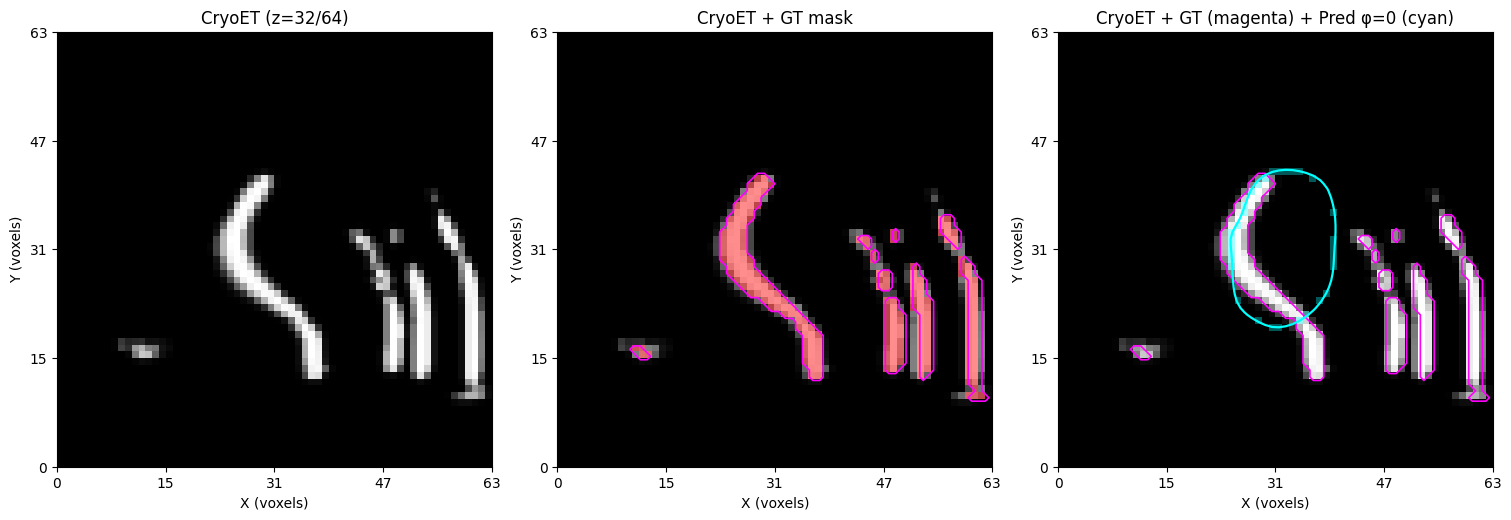

In [11]:
# --- Overlay a specific z-slice: CryoET, GT mask, and predicted phi=0 contour ---

import os, re
import numpy as np
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt

from pinn.cryoet_io import load_mrc_data
from pinn.train import create_train_state
from pinn.model import PINN

# -----------------------------
# Config: choose the slice
# -----------------------------
# Option A: pick normalized z in [-1, 1]
z_value = 0.0                       # e.g., mid-plane; change to -0.5, 0.25, etc.

# Option B: OR pick a voxel index directly (0..GRID_SIZE-1); set to None to use z_value
slice_index_override = None         # e.g., 32

# Optional: also show the predicted "narrow band" |phi| <= band as a semi-transparent overlay
epsilon = 0.05
band = 1.5 * epsilon                # tune 1.0~2.0 * epsilon if you want to see a band

# -----------------------------
# Paths
# -----------------------------
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}")
mask_file_path = f"../data/{data_dir}/{mask_shape}_mask.mrc"

# -----------------------------
# Helpers
# -----------------------------
def find_last_state_path(ckpt_dir):
    last_path, last_step = None, -1
    pat = re.compile(r"state_(\d{6})\.msgpack$")
    for fn in os.listdir(ckpt_dir):
        m = pat.match(fn)
        if m:
            s = int(m.group(1))
            if s > last_step:
                last_step = s
                last_path = os.path.join(ckpt_dir, fn)
    if last_path is None:
        raise FileNotFoundError(f"No state_*.msgpack in {ckpt_dir}")
    return last_path, last_step

def z_to_index(z, grid_size):
    # map normalized z in [-1,1] -> voxel index [0..grid_size-1]
    idx = int(np.round((float(z) + 1.0) * 0.5 * (grid_size - 1)))
    return int(np.clip(idx, 0, grid_size - 1))

# -----------------------------
# Restore model (latest checkpoint)
# -----------------------------
state_path, num_steps = find_last_state_path(checkpoint_dir)
dummy_key = jax.random.PRNGKey(0)
dummy_state, _ = create_train_state(dummy_key, lambda_1=lambda_1, lambda_2=lambda_2,
                                    sdf_pretrain=sdf_pretrain, learning_rate=1e-3)
restored_state = load_state_bytes(state_path, dummy_state)   # TrainState
params = restored_state.params
model = PINN()  # your defaults: hidden_dim=16, num_frequencies=10

# -----------------------------
# Load data and evaluate phi
# -----------------------------
cryoET = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)         # float [0,1]
gt_mask = (load_mrc_data(mask_file_path, grid_size=GRID_SIZE) > 0.5).astype(np.uint8)

g = jnp.linspace(-1, 1, GRID_SIZE)
X, Y, Z = jnp.meshgrid(g, g, g, indexing="ij")
pts = jnp.stack([X.ravel(), Y.ravel(), Z.ravel()], axis=-1)

phi = model.apply(params, pts).reshape(GRID_SIZE, GRID_SIZE, GRID_SIZE)

# -----------------------------
# Pick slice (z)
# -----------------------------
if slice_index_override is None:
    k = z_to_index(z_value, GRID_SIZE)
else:
    k = int(np.clip(slice_index_override, 0, GRID_SIZE-1))

cryo_sl = np.asarray(cryoET[:, :, k])
mask_sl = np.asarray(gt_mask[:, :, k])
phi_sl  = np.asarray(phi[:, :, k])

# For contour grids and voxel tick labels
xy_norm = np.linspace(-1, 1, GRID_SIZE)
extent = [xy_norm.min(), xy_norm.max(), xy_norm.min(), xy_norm.max()]
voxel_ticks = np.linspace(0, GRID_SIZE-1, 5).astype(int)
norm_ticks  = np.linspace(-1, 1, 5)

# -----------------------------
# Figure: (1) CryoET, (2) +GT overlay, (3) +Pred φ=0 and (optional) band
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

# (1) CryoET
axes[0].imshow(cryo_sl, cmap="gray", origin="lower", extent=extent)
axes[0].set_title(f"CryoET (z={k}/{GRID_SIZE})")
axes[0].set_xlabel("X (voxels)"); axes[0].set_ylabel("Y (voxels)")
axes[0].set_xticks(norm_ticks); axes[0].set_xticklabels(voxel_ticks)
axes[0].set_yticks(norm_ticks); axes[0].set_yticklabels(voxel_ticks)

# (2) GT mask overlay
axes[1].imshow(cryo_sl, cmap="gray", origin="lower", extent=extent)
axes[1].imshow(np.ma.masked_where(mask_sl == 0, mask_sl),
               cmap="autumn", origin="lower", extent=extent, alpha=0.45)
# GT contour (optional)
axes[1].contour(xy_norm, xy_norm, mask_sl, levels=[0.5], colors="magenta", linewidths=1.2)
axes[1].set_title("CryoET + GT mask")
axes[1].set_xlabel("X (voxels)"); axes[1].set_ylabel("Y (voxels)")
axes[1].set_xticks(norm_ticks); axes[1].set_xticklabels(voxel_ticks)
axes[1].set_yticks(norm_ticks); axes[1].set_yticklabels(voxel_ticks)

# (3) Combined: GT + predicted φ=0 (and optional band)
axes[2].imshow(cryo_sl, cmap="gray", origin="lower", extent=extent)

# Optional predicted band overlay: |phi| <= band
if band is not None and band > 0:
    pred_band = (np.abs(phi_sl) <= band).astype(np.uint8)
    axes[2].imshow(np.ma.masked_where(pred_band == 0, pred_band),
                   cmap="cool", origin="lower", extent=extent, alpha=0.35)

# GT contour (magenta) + φ=0 contour (cyan)
axes[2].contour(xy_norm, xy_norm, mask_sl, levels=[0.5], colors="magenta", linewidths=1.2)
axes[2].contour(xy_norm, xy_norm, phi_sl,  levels=[0.0], colors="cyan",    linewidths=1.6)
axes[2].set_title("CryoET + GT (magenta) + Pred φ=0 (cyan)")
axes[2].set_xlabel("X (voxels)"); axes[2].set_ylabel("Y (voxels)")
axes[2].set_xticks(norm_ticks); axes[2].set_xticklabels(voxel_ticks)
axes[2].set_yticks(norm_ticks); axes[2].set_yticklabels(voxel_ticks)

plt.show()


In [12]:
# === Movie: sweep through z, showing CryoET + GT + Pred overlays ===
import os, re
import numpy as np
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt
import imageio.v2 as imageio  # same API as imageio.get_writer
from pinn.cryoet_io import load_mrc_data
from pinn.train import create_train_state
from pinn.model import PINN

# -----------------------------
# Config
# -----------------------------
band_factor = 1.5        # show predicted |phi| <= band_factor * epsilon as a semi-transparent band
epsilon     = 0.05
fps         = 12
z_start, z_end, z_step = 0, None, 1   # None => last index; step controls stride (e.g., 2 to skip)
movie_name  = f"overlay_z_sweep_{shape}_lambda_{lambda_1}_{lambda_2}.mp4"

checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}")
mask_file_path = f"../data/{data_dir}/{mask_shape}_mask.mrc"

frames_dir = os.path.join(checkpoint_dir, "frames_overlay_z")
os.makedirs(frames_dir, exist_ok=True)
movie_path = os.path.join(checkpoint_dir, movie_name)

# -----------------------------
# Helpers
# -----------------------------
def find_last_state_path(ckpt_dir):
    last_path, last_step = None, -1
    pat = re.compile(r"state_(\d{6})\.msgpack$")
    for fn in os.listdir(ckpt_dir):
        m = pat.match(fn)
        if m:
            s = int(m.group(1))
            if s > last_step:
                last_step = s
                last_path = os.path.join(ckpt_dir, fn)
    if last_path is None:
        raise FileNotFoundError(f"No state_*.msgpack in {ckpt_dir}")
    return last_path, last_step

# -----------------------------
# Restore model (latest checkpoint)
# -----------------------------
state_path, num_steps = find_last_state_path(checkpoint_dir)
dummy_key = jax.random.PRNGKey(0)
dummy_state, _ = create_train_state(dummy_key, lambda_1=lambda_1, lambda_2=lambda_2,
                                    sdf_pretrain=sdf_pretrain, learning_rate=1e-3)
restored_state = load_state_bytes(state_path, dummy_state)   # TrainState
params = restored_state.params
model = PINN()

# -----------------------------
# Load data and evaluate phi
# -----------------------------
cryoET  = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)             # float [0,1]
gt_mask = (load_mrc_data(mask_file_path, grid_size=GRID_SIZE) > 0.5).astype(np.uint8)

g = jnp.linspace(-1, 1, GRID_SIZE)
X, Y, Z = jnp.meshgrid(g, g, g, indexing="ij")
pts = jnp.stack([X.ravel(), Y.ravel(), Z.ravel()], axis=-1)

phi = model.apply(params, pts).reshape(GRID_SIZE, GRID_SIZE, GRID_SIZE)

# Precompute axes helpers
xy_norm = np.linspace(-1, 1, GRID_SIZE)
extent  = [xy_norm.min(), xy_norm.max(), xy_norm.min(), xy_norm.max()]
voxel_ticks = np.linspace(0, GRID_SIZE-1, 5).astype(int)
norm_ticks  = np.linspace(-1, 1, 5)

band = band_factor * epsilon

# -----------------------------
# Render frames
# -----------------------------
if z_end is None:
    z_end = GRID_SIZE - 1
z_indices = list(range(int(z_start), int(z_end) + 1, int(z_step)))

for k in z_indices:
    cryo_sl = np.asarray(cryoET[:, :, k])
    mask_sl = np.asarray(gt_mask[:, :, k])
    phi_sl  = np.asarray(phi[:, :, k])

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

    # (1) CryoET
    axes[0].imshow(cryo_sl, cmap="gray", origin="lower", extent=extent)
    axes[0].set_title(f"CryoET (z={k}/{GRID_SIZE-1})")
    axes[0].set_xlabel("X (voxels)"); axes[0].set_ylabel("Y (voxels)")
    axes[0].set_xticks(norm_ticks); axes[0].set_xticklabels(voxel_ticks)
    axes[0].set_yticks(norm_ticks); axes[0].set_yticklabels(voxel_ticks)

    # (2) GT overlay
    axes[1].imshow(cryo_sl, cmap="gray", origin="lower", extent=extent)
    axes[1].imshow(np.ma.masked_where(mask_sl == 0, mask_sl),
                   cmap="autumn", origin="lower", extent=extent, alpha=0.45)
    axes[1].contour(xy_norm, xy_norm, mask_sl, levels=[0.5], colors="magenta", linewidths=1.2)
    axes[1].set_title("CryoET + GT mask")
    axes[1].set_xlabel("X (voxels)"); axes[1].set_ylabel("Y (voxels)")
    axes[1].set_xticks(norm_ticks); axes[1].set_xticklabels(voxel_ticks)
    axes[1].set_yticks(norm_ticks); axes[1].set_yticklabels(voxel_ticks)

    # (3) Combined: GT + predicted φ=0 (and the narrow band)
    axes[2].imshow(cryo_sl, cmap="gray", origin="lower", extent=extent)

    # Optional predicted band overlay: |phi| <= band
    if band is not None and band > 0:
        pred_band = (np.abs(phi_sl) <= band).astype(np.uint8)
        axes[2].imshow(np.ma.masked_where(pred_band == 0, pred_band),
                       cmap="cool", origin="lower", extent=extent, alpha=0.35)

    # GT contour (magenta) + φ=0 contour (cyan)
    axes[2].contour(xy_norm, xy_norm, mask_sl, levels=[0.5], colors="magenta", linewidths=1.2)
    axes[2].contour(xy_norm, xy_norm, phi_sl,  levels=[0.0], colors="cyan",    linewidths=1.6)
    axes[2].set_title(f"CryoET + GT (magenta) + Pred φ=0 (cyan)\nstep {num_steps}")
    axes[2].set_xlabel("X (voxels)"); axes[2].set_ylabel("Y (voxels)")
    axes[2].set_xticks(norm_ticks); axes[2].set_xticklabels(voxel_ticks)
    axes[2].set_yticks(norm_ticks); axes[2].set_yticklabels(voxel_ticks)

    frame_path = os.path.join(frames_dir, f"overlay_{k:04d}.png")
    plt.savefig(frame_path, dpi=140)
    plt.close(fig)

# -----------------------------
# Assemble MP4
# -----------------------------
with imageio.get_writer(movie_path, fps=fps) as writer:
    for k in z_indices:
        frame_path = os.path.join(frames_dir, f"overlay_{k:04d}.png")
        writer.append_data(imageio.imread(frame_path))

print("Wrote movie:", movie_path)


Pretraining the network using SDF...
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
Resizing MRC data from (128, 128, 128) to (64, 64, 64)


/home/minisemin/anaconda3/envs/pinn/lib/python3.11/subprocess.py:1885: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


Wrote movie: /home/minisemin/matsulab/pinn-exploration-model/outputs/logs/73_128_mask/lambda_1000000_500/overlay_z_sweep_73_128_mask_lambda_1000000_500.mp4
